## Preparation

In [1]:
# -- download data --

!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF # submission

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 45.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 8.49MB/s]
Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 4.88MB/s]


In [2]:
# -- install missing library --

!pip install category_encoders >> None

In [3]:
# -- import libraries --

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import json
from pathlib import Path
from typing import Dict, Any, List
from sklearn.preprocessing import OneHotEncoder
import joblib
import category_encoders as ce
import itertools
from copy import deepcopy
from tqdm import tqdm
from scipy import sparse
from scipy.stats import loguniform, randint, uniform

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import ParameterGrid, RandomizedSearchCV, train_test_split
from sklearn.base import clone
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [48]:
!pip freeze > requirements.txt

## EDA

In [4]:
# -- download train part --

data = pd.read_csv("game_of_thrones_train.csv", index_col="S.No")
data.head(2)

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1


In [5]:
# -- statistics on columns of type "object" --

data.describe(include='object').T

,count,unique,top,freq
name,1557,1557,Melara Hetherspoon,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


In [6]:
# -- statistics on numerical columns --

data.describe(include=["int64", "float64"]).T[['count', 'min', 'max']]

,count,min,max
male,1557.0,0.0,1.0
dateOfBirth,279.0,-25.0,299.0
book1,1557.0,0.0,1.0
book2,1557.0,0.0,1.0
book3,1557.0,0.0,1.0
book4,1557.0,0.0,1.0
book5,1557.0,0.0,1.0
isAliveMother,18.0,0.0,1.0
isAliveFather,22.0,0.0,1.0
isAliveHeir,21.0,0.0,1.0


In [7]:
# -- number of gaps in columns --

data.isna().sum()

,0
name,0
title,840
male,0
culture,1069
dateOfBirth,1278
mother,1539
father,1535
heir,1536
house,381
spouse,1357


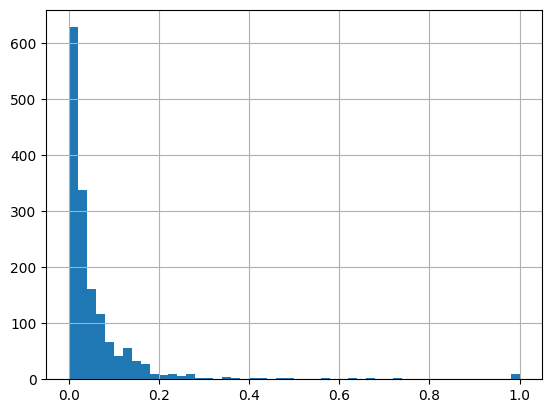

In [8]:
# -- histogram of the popularity distribution --

data.popularity.hist(bins=50);

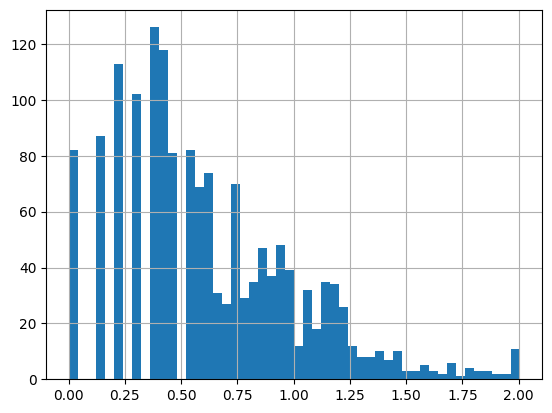

In [9]:
# -- transformation of the popularity feature using the formula --

M = 100
data[f"popularity_log_{M}"] = np.log10(data.popularity * M + 1)

data[f"popularity_log_{M}"].hist(bins=50);

In [10]:
# -- transformation of the popularity feature by quantiles --

data["popularity_cat_3"] = pd.qcut(data.popularity, 3, labels=[f"p3_{i}" for i in range(1, 4)])
data["popularity_cat_4"] = pd.qcut(data.popularity, 4, labels=[f"p4_{i}" for i in range(1, 5)])
data["popularity_cat_5"] = pd.qcut(data.popularity, 5, labels=[f"p5_{i}" for i in range(1, 6)])
data["popularity_cat_6"] = pd.qcut(data.popularity, 6, labels=[f"p6_{i}" for i in range(1, 7)])
data[["popularity", f"popularity_log_{M}", "popularity_cat_3", "popularity_cat_4", "popularity_cat_5", "popularity_cat_6"]].sample(3)

,popularity,popularity_log_100,popularity_cat_3,popularity_cat_4,popularity_cat_5,popularity_cat_6
S.No,,,,,,
507,0.739130,1.874557,p3_3,p4_4,p5_5,p6_6
149,0.030100,0.603148,p3_2,p4_3,p5_3,p6_4
1192,0.170569,1.256642,p3_3,p4_4,p5_5,p6_6


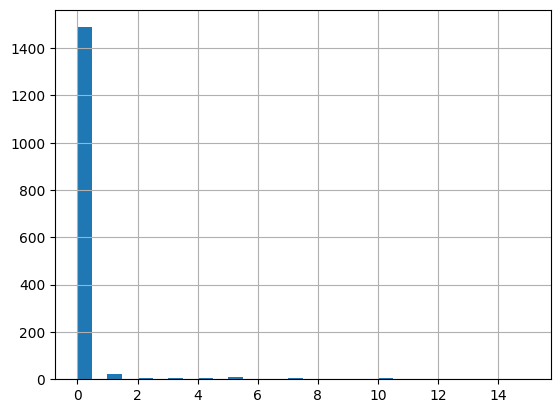

In [11]:
# -- histogram of the distribution of the numDeadRelations feature --

data.numDeadRelations.hist(bins=30);

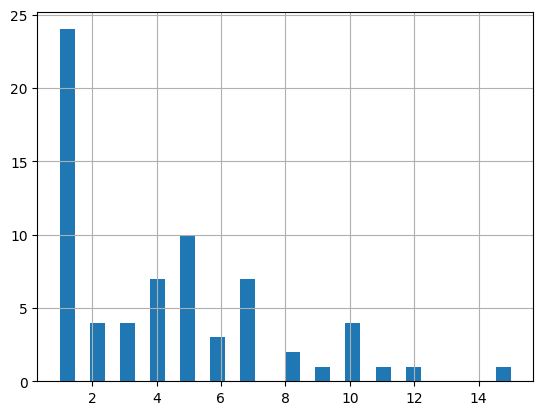

In [12]:
# -- histogram of the same feature without value 0 --

data[data.numDeadRelations != 0].numDeadRelations.hist(bins=30);

In [13]:
# -- converting the numDeadRelations attribute to binary --

data["boolDeadRelations"] = (data.numDeadRelations > 0).astype("int64")

In [14]:
# -- create an additional feature age_no_data --

# if there is a gap in age / dateOfBirth (similar gaps), then the age_no_data
# column will be 1, otherwise 0, and the age_value / dateOfBirth_value column
# will be 0 if the value is missing and the normal value if not missing.

data['age_value'] = data["age"].fillna(0)
data['dateOfBirth_value'] = data["dateOfBirth"].fillna(0)
data['age_no_data'] = [1 if np.isnan(x) else 0 for x in data['age']]
data.head(3)

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAlive,popularity_log_100,popularity_cat_3,popularity_cat_4,popularity_cat_5,popularity_cat_6,boolDeadRelations,age_value,dateOfBirth_value,age_no_data
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,0,1.789123,p3_3,p4_4,p5_5,p6_6,1,0.0,0.0,1
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,1,1.957282,p3_3,p4_4,p5_5,p6_6,1,97.0,208.0,0
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,1,1.443355,p3_3,p4_4,p5_5,p6_6,0,0.0,0.0,1


In [15]:
# -- distribution of values ​​of the culture feature --

data['culture'].value_counts(dropna=False)

,count
culture,
NaN,1069
Northmen,94
Ironborn,91
Free Folk,45
Braavosi,39
Valyrian,28
Ghiscari,17
Dornish,17
Dothraki,17


In [17]:
def invert_dict(d):
    '''
    inverts the dictionary so that the keys of the new dictionary are
    the values ​​of the old one, and the values ​​are the corresponding keys
    of the old one.
    '''
    d_inverted = {}
    for k in d.keys():
        for v in d[k]:
            d_inverted.update({v: k})

    return d_inverted

invert_dict({1: list("abc"), 2: list("defg")})

{'a': 1, 'b': 1, 'c': 1, 'd': 2, 'e': 2, 'f': 2, 'g': 2}

In [18]:
# -- create a dictionary for transforming the cultural feature --

# grouping by peoples
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

In [19]:
# -- create a dictionary for mapping the values ​​of the culture feature --

cultures_grouped_inverted = invert_dict(cultures_grouped)

In [20]:
# -- transforming the culture column by aggregated groups --

data['culture_grouped'] = data['culture'].str.lower().map(cultures_grouped_inverted)

In [21]:
# -- replace the gaps with culture_no_data --

data['culture_grouped'] = data['culture_grouped'].fillna("culture_no_data")
data[['name', 'culture_grouped']].sample(3)

,name,culture_grouped
S.No,,
1241,Moribald Chester,culture_no_data
2,Walder Frey,the Isles and Rivers
826,Orivel,culture_no_data


In [22]:
# -- look at the aggregation result after the changes --

data['culture_grouped'].value_counts(dropna=False)

,count
culture_grouped,
culture_no_data,1069
Essos Nations,109
the North,108
the Iron Islands,95
Other Nations,57
Old Nations,32
the Mountain and the Vale,25
Dorne,21
the Rock,14


In [23]:
# -- the number of unique values ​​in each column --

data.nunique()

,0
name,1557
title,195
male,2
culture,51
dateOfBirth,105
mother,16
father,19
heir,20
house,315
spouse,186


In [24]:
# -- comparison of average values ​​of the target by the values ​​of the feature --

data.groupby('isAliveSpouse', dropna=False)['isAlive'].mean()

,isAlive
isAliveSpouse,
0.0,0.619048
1.0,0.753165
NaN,0.786293


In [25]:
# -- similar comparison + number of gaps --

pd.pivot_table(data=data, values='isAlive', index='isAliveSpouse', aggfunc=['mean', 'count'], dropna=False)

,mean,count
,isAlive,isAlive
isAliveSpouse,,
0.0,0.619048,42
1.0,0.753165,158
NaN,0.786293,1357


## FE + Models selection

### Functions

In [26]:
# To test different grouping options, we will create a JSON file
# that will contain dictionaries with mapping options.

def load_groups(path: str) -> dict:
    '''
    Loads a file with different groupings.
    '''
    p = Path(path)
    with p.open("r", encoding="UTF-8") as f:
        data = json.load(f)
    return {k: v for k, v in data.items() if isinstance(v, dict)}

In [27]:
def invert_dict(d: Dict[str, List[str]]) -> Dict[str, str]:
    '''
    Inverts the dictionary so that the keys of the new dictionary are
    the values ​​of the old one, and the values ​​are the corresponding keys
    of the old one.
    '''
    d_inverted = {}
    for k in d.keys():
        for v in d[k]:
            d_inverted.update({v: k})

    return d_inverted

In [29]:
def make_key(*cfg):
    '''
    Creates a key based on the config parameters.
    '''
    cfg = [ *cfg[:5], ";".join(map(str, cfg[5])), *cfg[6:]]
    return "-".join(map(str, cfg))

In [30]:
def load_config(
                    M=100,
                    q=4,
                    cultures_grouped=None,
                    titles_grouped=None,
                    popularity_type="F",                                      # F (formula) / Q (quantiles)
                    houses_count_groupes=[[0, 2], [3, 4], [5, 8], [9, 17]],
                    isAliveHeir_processing_type="B",                          # B (binary) / M (multivalued)
                    isAliveFather_processing_type="B",                        # B (binary) / M (multivalued)
                    isAliveSpouse_processing_type="B",                        # B (binary) / M (multivalued)
                    encoding_type="onehot",                                   # onehot / target
                    target_col="isAlive",
                    encoder_path="/content/encoder.pkl",
                    scaler_path="/content/scaler.pkl",
                    return_key=False,
                ) -> Dict[str, Any]:
    '''
    Loads parameters for processing the dataset.
    '''
    dicts = load_groups("dicts.json")
    # dictionary for converting binary columns with gaps
    binary_mapping = {np.nan: 0, 0: 1, 1: 2}
    if not cultures_grouped:
        cultures_grouped = "cultures_grouped"
    if not titles_grouped:
        titles_grouped = "titles_normalized"
    cultures_grouped_dict = dicts.get(cultures_grouped)
    titles_grouped_dict = dicts.get(titles_grouped)
    result = {
        "M": M,
        "q": q,
        "cultures_grouped_dict": cultures_grouped_dict,
        "titles_grouped_dict": titles_grouped_dict,
        "popularity_type": popularity_type,
        "houses_count_groupes": houses_count_groupes,
        "isAliveHeir_processing_type": isAliveHeir_processing_type,
        "isAliveFather_processing_type": isAliveFather_processing_type,
        "isAliveSpouse_processing_type": isAliveSpouse_processing_type,
        "binary_mapping": binary_mapping,
        "encoding_type": encoding_type,
        "target_col": target_col,
        "encoder_path": encoder_path,
        "scaler_path": scaler_path,
    }
    if return_key:
        key = make_key(
            M,
            q,
            cultures_grouped,
            titles_grouped,
            popularity_type,
            houses_count_groupes,
            isAliveHeir_processing_type,
            isAliveFather_processing_type,
            isAliveSpouse_processing_type,
            encoding_type
        )
        return (result, key)
    else:
        return result

In [31]:
def get_config_by_key(key, encoder_path, scaler_path):
    '''
    Decodes the config by its key.
    '''
    params = key.split('-')
    return load_config(
        M=params[0],
        q=params[1],
        cultures_grouped=params[2],
        titles_grouped=params[3],
        popularity_type=params[4],
        houses_count_groupes=[list(map(int, i[1:-1].split(','))) for i in key.split('-')[5].split(';')],
        isAliveHeir_processing_type=params[6],
        isAliveFather_processing_type=params[7],
        isAliveSpouse_processing_type=params[8],
        encoding_type=params[9],
        target_col="isAlive",
        encoder_path=encoder_path,
        scaler_path=scaler_path,
    )

In [32]:
def pipeline_transform(
        df: pd.DataFrame,
        df_another: pd.DataFrame,
        config: Dict[str, Any],
        mode: str = "train" # train / test
    ) -> pd.DataFrame:
    '''
    Implements a dataset transformation pipeline:

    1. Removes/corrects the original datasets.
    2. Applies two types of transformation to the popularity column: one based
    on the logarithmic formula and one based on quantiles.
    3. Creates a boolDeadRelations column based on numDeadRelations.
    4. Creates age_value and dateOfBirth_value columns based on age and
    dateOfBirth, respectively, and a binary column, age_no_data.
    5. Applies grouping to the culture column.
    6. Applies grouping to the title column.
    7. Transforms the heir column to a boolean.
    8. Modifies the house column as follows: houses with a large number of
    members remain unchanged, houses with a small number of members are grouped
    and assigned the same categorical label within the group.
    9. Removes unnecessary, uninformative columns.
    10. Transforms the isAliveMother column into a Boolean.
    11. Applies two types of transformation to the isAliveFather, isAliveSpouse,
    and isAliveHeir columns: either makes them Boolean or skip-encodes them and
    turns them into multi-valued categorical columns.

    Returns the modified dataset, a list of categorical columns of
    the resulting dataset, and a list of numerical columns of
    the resulting dataset.
    '''
    df_ = df.copy()

    if mode == "test":
        df_.loc[1877, "title"] = "Prince of Winterfell"
        df_.loc[1685, 'dateOfBirth'] = 278.
        df_.loc[1869, 'dateOfBirth'] = 299.
        df_.loc[1685, 'age'] = 0.
        df_.loc[1869, 'age'] = 0.
    elif mode == "train":
        df_ = df_.drop(index=[1391])

    # list of multi-valued categorical columns
    categorical_columns = []
    # list of numeric columns
    numerical_columns = []

    if "popularity" in df_.columns:
        if config["popularity_type"] == "F":
            M = int(config["M"])
            df_[f"popularity_log_{M}"] = np.log10(df_["popularity"] * M + 1)
            df_ = df_.drop(columns=["popularity"])
            numerical_columns.append(f"popularity_log_{M}")
        elif config["popularity_type"] == "Q":
            q = int(config["q"])
            df_[f"popularity_categories_{q}"] = pd.qcut(df_["popularity"], q, labels=[f"p{q}_{i}" for i in range(1, q+1)])
            df_ = df_.drop(columns=["popularity"])
            categorical_columns.append(f"popularity_categories_{q}")

    if "numDeadRelations" in df_.columns:
        df_["boolDeadRelations"] = (df_["numDeadRelations"].fillna(0) > 0).astype("int64")
        df_ = df_.drop(columns=["numDeadRelations"])

    if ("age" in df_.columns) and ("dateOfBirth" in df_.columns):
        df_["age_value"] = df_["age"].fillna(0)
        df_["age_no_data"] = df_["age"].isna().astype("int64")
        df_["dateOfBirth_value"] = df_["dateOfBirth"].fillna(0)
        df_ = df_.drop(columns=["age", "dateOfBirth"])
        numerical_columns.append("age_value")
        numerical_columns.append("dateOfBirth_value")

    if "culture" in df_.columns:
        cultures_grouped_inverted = invert_dict(config["cultures_grouped_dict"])
        df_["culture_grouped"] = df_["culture"].astype(str).str.lower().map(cultures_grouped_inverted).fillna("culture_no_data")
        df_ = df_.drop(columns=["culture"])
        categorical_columns.append("culture_grouped")

    if "title" in df_.columns:
        df_["title"] = df_["title"].str.lower()
        title_groups_inverted = invert_dict(config["titles_grouped_dict"])
        df_["title_grouped"] = df_["title"].map(title_groups_inverted)
        df_["title_grouped"] = df_["title_grouped"].fillna("title_no_data")
        df_ = df_.drop(columns=["title"])
        categorical_columns.append("title_grouped")

    if "heir" in df_.columns:
        df_["heir_bool"] = (~df_.heir.isna()).astype("int64")
        df_ = df_.drop(columns=["heir"])

    if "house" in df_.columns:
        combined_houses = pd.concat([df_["house"], df_another["house"]], axis=0)
        house_counts = combined_houses.fillna("house_no_data").value_counts()
        house_groups = {}
        for house, cnt in house_counts.items():
            if house == "house_no_data":
                house_groups[house] = "house_no_data"
            else:
                for k, house_cnt_group in enumerate(config["houses_count_groupes"]):
                    if house_cnt_group[0] <= cnt <= house_cnt_group[1]:
                        house_groups[house] = f'h_{k+1}'
                        break
                else:
                    house_groups[house] = house
        df_["house_grouped"] = df_["house"].fillna("house_no_data").map(house_groups)
        df_ = df_.drop(columns=["house"])
        categorical_columns.append("house_grouped")

    if "mother" in df_.columns:
        df_ = df_.drop(columns=["mother"])

    if "father" in df_.columns:
        df_ = df_.drop(columns=["father"])

    if "spouse" in df_.columns:
        df_ = df_.drop(columns=["spouse"])

    if "name" in df_.columns:
        df_ = df_.drop(columns=["name"])

    if "isAliveMother" in df_.columns:
        df_["boolMotherIndicated"] = (~df_['isAliveMother'].isna()).astype("int64")
        df_ = df_.drop(columns=["isAliveMother"])

    if "isAliveFather" in df_.columns:
        if config["isAliveFather_processing_type"] == "B":
            df_["boolFatherIndicated"] = (~df_['isAliveFather'].isna()).astype("int64")
            df_ = df_.drop(columns=["isAliveFather"])
        elif config["isAliveFather_processing_type"] == "M":
            df_["isAliveFather"] = df_["isAliveFather"].replace(config["binary_mapping"])
            categorical_columns.append("isAliveFather")

    if "isAliveSpouse" in df_.columns:
        if config["isAliveSpouse_processing_type"] == "B":
            df_["boolSpouseIndicated"] = (~df_['isAliveSpouse'].isna()).astype("int64")
            df_ = df_.drop(columns=["isAliveSpouse"])
        elif config["isAliveSpouse_processing_type"] == "M":
            df_["isAliveSpouse"] = df_["isAliveSpouse"].replace(config["binary_mapping"])
            categorical_columns.append("isAliveSpouse")

    if "isAliveHeir" in df_.columns:
        if config["isAliveHeir_processing_type"] == "B":
            df_["boolHeirIndicated"] = (~df_['isAliveHeir'].isna()).astype("int64")
            df_ = df_.drop(columns=["isAliveHeir"])
        elif config["isAliveHeir_processing_type"] == "M":
            df_["isAliveHeir"] = df_["isAliveHeir"].replace(config["binary_mapping"])
            categorical_columns.append("isAliveHeir")

    return df_.copy(), categorical_columns, numerical_columns

In [33]:
def pipeline_encode(
        df: pd.DataFrame,
        config: Dict[str, Any],
        categorical_columns: List[str],
        numerical_columns: List[str],
        mode: str = "fit_transform" # fit_transform / transform
    ) -> pd.DataFrame:
    '''
    Implements a dataset encoding pipeline.

    Works in 2 modes:
    1. Fit_transform:
        - Creates Scaler. Scales numerical columns;
        - Creates Encoder. Encodes categorical columns.
    2. Transform:
        - Loads Scaler. Scales numerical columns;
        - Loads Encoder. Encodes categorical columns.

    Returns the modified dataset, a scaler, and an encoder.
    '''
    df_ = df.copy()
    enc_type = config.get("encoding_type")
    target_col = config.get("target_col")
    encoder_path = config.get("encoder_path")
    scaler_path = config.get("scaler_path")

    if mode == "fit_transform":
        scaler = StandardScaler()
        df_[numerical_columns] = scaler.fit_transform(df_[numerical_columns])
    elif mode == "transform":
        scaler = joblib.load(scaler_path)
        df_[numerical_columns] = scaler.transform(df_[numerical_columns])

    if enc_type == "target":
        if mode == "fit_transform":
            enc = ce.TargetEncoder(cols=categorical_columns)
            enc.fit(df_[categorical_columns], df_[target_col])
        elif mode == "transform":
            enc = joblib.load(encoder_path)
        df_[categorical_columns] = enc.transform(df_[categorical_columns])

    elif enc_type == "onehot":
        if mode == "fit_transform":
            enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
            enc.fit(df_[categorical_columns].astype(str))
        elif mode == "transform":
            enc = joblib.load(encoder_path)

        columns_transformed = enc.get_feature_names_out(categorical_columns)
        arr_transformed = enc.transform(df_[categorical_columns].astype(str))
        df_ohe = pd.DataFrame(arr_transformed, index=df_.index, columns=columns_transformed)
        df_ = pd.concat([df_.drop(columns=categorical_columns), df_ohe], axis=1)

    return df_, scaler, enc

In [35]:
def train_models(df: pd.DataFrame,
                 models: Dict[str, Any]) -> pd.Series:
    '''
    This function is designed to select the best model using grid search.

    1. Splits the data into training and validation sets;
    2. Iterates through the provided models and their parameter grids;
    3. Trains each model on the training data;
    4. Evaluates the model on the validation data using accuracy;

    Returns model with the best accuracy.
    '''
    X = df.drop(columns="isAlive")
    y = data_result_encoded["isAlive"]
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.8, train_size=0.2, random_state=42, stratify=y)

    results = []
    for model_name, (model_base, grid) in models.items():

        param_grid = list(ParameterGrid(grid))

        for params in param_grid:
            clf = clone(model_base).set_params(**params)
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_val)
            acc = accuracy_score(y_val, y_pred)
            results.append({'model': model_name, 'params': params, 'val_accuracy': acc})

    model_best_result = pd.DataFrame(results).sort_values('val_accuracy', ascending=False).reset_index(drop=True).loc[0, :]

    return model_best_result

In [36]:
def train_models_randomsearch(df: pd.DataFrame,
                              config: Dict[str, Any],
                              models: Dict[str, Any]) -> pd.Series:
    '''
    This function is designed to select the best model using random search.

    1. Splits the data into training and validation sets;
    2. Firstly iterates through the models using random search based on
    a subset of the train part;
    3. Trains each model on the subset of training data using random search;
    4. Selects the best model based on random search and
    trains it on full train data;
    5. Evaluates the model on the validation data using accuracy;

    Returns model with the best accuracy.
    '''
    cfg = {
        "n_iter": 5,
        "cv": 3,
        "scoring": "accuracy",
        "random_state": 42,
        "n_jobs": -1,
        "test_size": 0.2,
        "verbose": 0,
        "search_sample_frac": 0.2,
    }
    cfg.update(config or {})

    X = df.drop(columns="isAlive")
    y = df["isAlive"]

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=cfg["test_size"], random_state=cfg["random_state"], stratify=y
    )
    X_search = X_train.sample(n=int(len(X_train) * cfg["search_sample_frac"]),
                              random_state=cfg["random_state"])
    y_search = y_train.loc[X_search.index]

    results = []

    for model_name, (model_base, param_dist) in models.items():

        # if there're no hyperparameters, we simply train the base model
        if not param_dist:
            est = clone(model_base)
            est.fit(X_train, y_train)
            y_pred = est.predict(X_val)
            acc = accuracy_score(y_val, y_pred)

            results.append({
                "model": model_name,
                "params": est.get_params(),
                "val_accuracy": acc,
            })
            continue

        estimator = clone(model_base)
        rnd = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=param_dist,
            n_iter=cfg["n_iter"],
            cv=cfg["cv"],
            scoring=cfg["scoring"],
            n_jobs=cfg["n_jobs"],
            random_state=cfg["random_state"],
            verbose=cfg["verbose"],
            refit=False
        )

        rnd.fit(X_search, y_search)
        best_params = rnd.best_params_

        best_full = clone(model_base).set_params(**best_params)
        best_full.fit(X_train, y_train)

        y_pred = best_full.predict(X_val)
        acc = accuracy_score(y_val, y_pred)

        results.append({
            "model": model_name,
            "params": best_params,
            "val_accuracy": acc,
        })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values("val_accuracy", ascending=False).reset_index(drop=True)

    return results_df.loc[0]

In [37]:
def parse_config_list(str_list):
    '''
    Gets the config passed as a string.
    '''
    safe_globals = {"__builtins__": None} # denies access to standard built-in objects
    safe_locals = {"nan": float("nan")}
    return [eval(s, safe_globals, safe_locals) for s in str_list]

In [47]:
def make_submission_simple(df_train, df_test, model, config, file_name="new_submission"):
    '''
    Receives the transformed training and test datasets and the model as input.
    Returns submission file.
    '''
    X_train = df_train.drop(columns="isAlive")
    y_train = df_train["isAlive"]

    model.fit(X_train, y_train)

    y_test = model.predict(df_test)
    submission = pd.read_csv("/content/submission.csv", index_col='S.No')
    submission['isAlive'] = y_test
    submission.to_csv(f"/content/{file_name}.csv", index=False)

### Grids for datasets and models

#### Models grids

In [41]:
# -- Grid search mesh --
# Not used because of the iteration time
models = {
    'LogisticRegression': (LogisticRegression(max_iter=10_000, random_state=42,
                                              solver='saga', n_jobs=-1), {
            'C': [0.1, 1, 10],
            'penalty': ['l2', 'l1'],
            'class_weight': [None, 'balanced'],
            'solver': ['saga']
    }),
    'RandomForest': (RandomForestClassifier(random_state=42, n_jobs=-1), {
            'n_estimators': [100, 200],
            'max_depth': [None, 20],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
            'max_features': ['sqrt'],
            'class_weight': [None, 'balanced']
    }),
    'AdaBoost': (AdaBoostClassifier(random_state=42), {
            'n_estimators': [50, 200],
            'learning_rate': [0.05, 0.1],
    }),
    'GaussianNB': (GaussianNB(), {
    }),
    'KNN': (KNeighborsClassifier(n_jobs=-1), {
            'n_neighbors': [3, 5],
            'weights': ['uniform', 'distance'],
            'p': [1, 2]
    }),
    'SVC': (SVC(random_state=42, probability=True), {
            'C': [0.1, 1],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale'],
            'class_weight': [None]
    }),
    'DecisionTree': (DecisionTreeClassifier(random_state=42), {
            'max_depth': [None, 10],
            'min_samples_split': [2, 10],
            'min_samples_leaf': [1, 4],
            'criterion': ['gini'],
            'class_weight': [None]
    })
}

In [42]:
# -- Random search mesh --
# Used for basic model selection
models_dist = {
    'LogisticRegression': (LogisticRegression(max_iter=10_000, random_state=42, n_jobs=1), {
        'C': loguniform(1e-4, 1e2),
        'penalty': ['l2', 'l1'],
        'class_weight': [None, 'balanced'],
        'solver': ['saga'],
    }),
    'RandomForest': (RandomForestClassifier(random_state=42, n_jobs=1), {
        'n_estimators': randint(30, 301),
        'max_depth': randint(3, 51),
        'min_samples_split': randint(2, 11),
        'min_samples_leaf': randint(1, 6),
        'max_features': ['sqrt', 'log2', None],
        'class_weight': [None, 'balanced']
    }),
    'AdaBoost': (AdaBoostClassifier(random_state=42), {
        'n_estimators': randint(20, 501),
        'learning_rate': loguniform(1e-3, 1.0)
    }),
    'GaussianNB': (GaussianNB(),
        {}   # no hyperparameters
    ),
    'KNN': (KNeighborsClassifier(n_jobs=1), {
        'n_neighbors': randint(1, 21),
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    }),
    'SVC': (SVC(random_state=42, probability=False), {
        'C': loguniform(1e-3, 1e2),
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    }),
    'DecisionTree': (DecisionTreeClassifier(random_state=42),{
        'max_depth': randint(3, 51),
        'min_samples_split': randint(2, 21),
        'min_samples_leaf': randint(1, 11),
        'criterion': ['gini', 'entropy'],
        'class_weight': [None, 'balanced']
    })
}

In [43]:
# -- Random search mesh for Random Forest --
# Used to select model parameters and dataset
models_rf = {
    'RandomForest': (RandomForestClassifier(random_state=42, n_jobs=1), {
            'n_estimators': randint(100, 301),
            'max_depth': randint(20, 51),
            'min_samples_split': randint(2, 16),
            'min_samples_leaf': randint(1, 6),
            'max_features': ['log2', None, 'sqrt'],
            'class_weight': [None, 'balanced'],
            'bootstrap': [True, False],
            'criterion': ['gini', 'entropy'],
            'max_leaf_nodes': randint(50, 501)
        }
    )
}

#### Dataset grids

In [45]:
# -- Standart dataset parameters grid --
# Used for basic model selection
param_grid = {
    "M": [100, 200],
    "q": [3, 4, 5],
    "cultures_grouped": [
        'cultures_grouped',
        # 'cultures_grouped_by_continent',
        'cultures_grouped_by_societal_type',
        # 'cultures_variant_region_fine',
        # 'cultures_variant_by_society',
        # 'cultures_variant_binary_continent_plus_type',
    ],
    "titles_grouped": [
        # 'titles_grouped_by_rank',
        'titles_grouped_by_function',
        'titles_normalized',
        # 'titles_variant_functional_strict',
        # 'titles_variant_level_based',
        # 'titles_variant_binary_flags_for_ml',
    ],
    "popularity_type": ["F","Q"],
    "houses_count_groupes": [
        [[0,2],[3,4],[5,8],[9,17]],
        [[0,1],[2,3],[4,10],[11,20]]
    ],
    "isAliveHeir_processing_type": ["B","M"],
    "isAliveFather_processing_type": ["B","M"],
    "isAliveSpouse_processing_type": ["B","M"],
    "encoding_type": ["onehot","target"],
    "encoder_path": ["/content/encoders/enc_{i}.pkl"],
    "scaler_path": ["/content/scalers/scaler_{i}.pkl"],
}

In [46]:
# -- More local dataset parameters grid + checking other groupings --
# Used to select model parameters and dataset
new_param_grid = {
    "M": [100],
    "q": [4, 5],
    "cultures_grouped": [
        # 'cultures_grouped',
        'cultures_grouped_by_continent',
        # 'cultures_grouped_by_societal_type',
        'cultures_variant_region_fine',
        'cultures_variant_by_society',
        # 'cultures_variant_binary_continent_plus_type',
    ],
    "titles_grouped": [
        'titles_grouped_by_rank',
        # 'titles_grouped_by_function',
        # 'titles_normalized',
        'titles_variant_functional_strict',
        'titles_variant_level_based',
        # 'titles_variant_binary_flags_for_ml',
    ],
    "popularity_type": ["F","Q"],
    "houses_count_groupes": [
        [[0,2],[3,4],[5,8],[9,17]],
        # [[0,1],[2,3],[4,10],[11,20]]
    ],
    "isAliveHeir_processing_type": ["B","M"],
    "isAliveFather_processing_type": ["B","M"],
    "isAliveSpouse_processing_type": ["B","M"],
    "encoding_type": ["onehot","target"],
    "encoder_path": ["/content/encoders/new_enc_{i}.pkl"],
    "scaler_path": ["/content/scalers/new_scaler_{i}.pkl"],
}

### Base

*P.S.: Some intermediate steps in the model selection process have been removed from the notebook to improve the visual experience.*

**Grouping options for the culture and title features based on dicts.json:**

*culture*:
- cultures_grouped
- cultures_grouped_by_continent
- cultures_grouped_by_societal_type
- cultures_variant_region_fine
- cultures_variant_by_society
- cultures_variant_binary_continent_plus_type

*title*:
- titles_grouped_by_rank
- titles_grouped_by_function
- titles_normalized
- titles_variant_functional_strict
- titles_variant_level_based
- titles_variant_binary_flags_for_ml

#### First pass

In [ ]:
all_combinations = None

data = pd.read_csv("game_of_thrones_train.csv", index_col="S.No")
data_test = pd.read_csv("game_of_thrones_test.csv", index_col="S.No")

keys = list(param_grid.keys())
if not all_combinations:
    all_combinations = list(itertools.product(*list(param_grid.values())))

# printed -- Combinations all
print("Всего комбинаций:", len(all_combinations))

all_dfs = {}

for i, combination in tqdm(enumerate(all_combinations)):
    cfg_vals = dict(zip(keys, combination))
    cfg, key = load_config(
        M=cfg_vals["M"],
        q=cfg_vals["q"],
        cultures_grouped=cfg_vals["cultures_grouped"],
        titles_grouped=cfg_vals["titles_grouped"],
        popularity_type=cfg_vals["popularity_type"],
        houses_count_groupes=cfg_vals["houses_count_groupes"],
        isAliveHeir_processing_type=cfg_vals["isAliveHeir_processing_type"],
        isAliveFather_processing_type=cfg_vals["isAliveFather_processing_type"],
        isAliveSpouse_processing_type=cfg_vals["isAliveSpouse_processing_type"],
        encoding_type=cfg_vals["encoding_type"],
        return_key=True,
    )

    data_result, categorical_columns, numerical_columns = \
    pipeline_transform(data, data_test, cfg)

    # create a folder (if it doesn't exist yet) and a file for the encoder
    encoder_path_pattern = cfg_vals["encoder_path"]
    p = encoder_path_pattern.format(i=i)
    Path(Path(p).parent).mkdir(parents=True, exist_ok=True)
    cfg["encoder_path"] = p

    # create a folder (if it doesn't exist yet) and a file for scaler
    scaler_path_pattern = cfg_vals["scaler_path"]
    p = scaler_path_pattern.format(i=i)
    Path(Path(p).parent).mkdir(parents=True, exist_ok=True)
    cfg["scaler_path"] = p

    data_result_encoded, scaler_obj, enc_obj = \
    pipeline_encode(data_result, cfg, categorical_columns, numerical_columns, mode="fit_transform")
    if cfg["encoder_path"] and enc_obj is not None:
        joblib.dump(enc_obj, cfg["encoder_path"])
    if cfg["scaler_path"] and scaler_obj is not None:
        joblib.dump(scaler_obj, cfg["scaler_path"])

    all_dfs[key] = (data_result_encoded, cfg["encoder_path"], cfg["scaler_path"])

Всего комбинаций: 1536


1536it [01:04, 23.84it/s]


In [ ]:
results = []

for i, (key_current, item_current) in tqdm(enumerate(all_dfs.items())):
    df_current = item_current[0]
    cfg_current = get_config_by_key(key_current, item_current[1], item_current[2])
    model_result = train_models_randomsearch(df_current, {"n_iter": 5}, models_dist).to_dict()
    results.append({'i': i, 'accuracy': model_result['val_accuracy'],
                    'config': cfg_current, 'model_result': model_result})

df_final = pd.DataFrame(results)
df_final.to_csv("df_final.csv")

df_final.sort_values('accuracy', ascending=False).reset_index(drop=True)

1536it [3:02:29,  7.13s/it]


,i,accuracy,config,model_result
0,16,0.842949,"{'M': '100', 'q': '3', 'cultures_grouped_dict'...","{'model': 'KNN', 'params': {'n_neighbors': 11,..."
1,528,0.842949,"{'M': '100', 'q': '5', 'cultures_grouped_dict'...","{'model': 'KNN', 'params': {'n_neighbors': 11,..."
2,532,0.842949,"{'M': '100', 'q': '5', 'cultures_grouped_dict'...","{'model': 'KNN', 'params': {'n_neighbors': 11,..."
3,536,0.842949,"{'M': '100', 'q': '5', 'cultures_grouped_dict'...","{'model': 'KNN', 'params': {'n_neighbors': 11,..."
4,540,0.842949,"{'M': '100', 'q': '5', 'cultures_grouped_dict'...","{'model': 'KNN', 'params': {'n_neighbors': 11,..."
...,...,...,...,...
1531,420,0.788462,"{'M': '100', 'q': '4', 'cultures_grouped_dict'...","{'model': 'RandomForest', 'params': {'class_we..."
1532,288,0.785256,"{'M': '100', 'q': '4', 'cultures_grouped_dict'...","{'model': 'LogisticRegression', 'params': {'C'..."
1533,416,0.785256,"{'M': '100', 'q': '4', 'cultures_grouped_dict'...","{'model': 'LogisticRegression', 'params': {'C'..."
1534,1184,0.785256,"{'M': '200', 'q': '4', 'cultures_grouped_dict'...","{'model': 'LogisticRegression', 'params': {'C'..."


In [ ]:
i_final, config_final, model_final = df_final.sort_values('accuracy', ascending=False)\
                                     .reset_index(drop=True)\
                                     .loc[0, ['i', 'config', 'model_result']]

model_final

{'model': 'KNN',
 'params': {'n_neighbors': 11, 'p': 1, 'weights': 'distance'},
 'val_accuracy': 0.842948717948718}

In [ ]:
data_test_result, categorical_columns, numerical_columns = \
pipeline_transform(data_test, data, config_final, mode="test")

data_test_result_encoded, scaler_obj, enc_obj = \
pipeline_encode(data_test_result, config_final, categorical_columns, \
                numerical_columns, mode="transform")

data_test_result_encoded.head(3)

,male,book1,book2,book3,book4,book5,isMarried,isNoble,popularity_log_100,boolDeadRelations,...,house_grouped_House Osgrey,house_grouped_House Stark,house_grouped_House Targaryen,house_grouped_House Tyrell,house_grouped_Night's Watch,house_grouped_h_1,house_grouped_h_2,house_grouped_h_3,house_grouped_h_4,house_grouped_house_no_data
S.No,,,,,,,,,,,,,,,,,,,,,
1558,0,0,0,0,0,1,0,0,0.392894,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1559,0,0,1,1,1,1,0,0,3.122607,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1560,0,0,0,1,1,0,0,0,-0.793324,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


> **Explanation:**

Since the primary goal was to obtain **a metric (accuracy) > 0.75** on the test dataset (for which there were no values ​​for the target variable), model selection was performed by checking the submission metric. By reviewing the file containing the resulting models and generating submission files, it was concluded that the Random Forest model performed best for this task, and the number of parameters tested for the dataset was slightly reduced.

#### Second pass

In [ ]:
new_all_combinations = None

data = pd.read_csv("game_of_thrones_train.csv", index_col="S.No")
data_test = pd.read_csv("game_of_thrones_test.csv", index_col="S.No")

keys = list(new_param_grid.keys())
if not new_all_combinations:
    new_all_combinations = list(itertools.product(*list(new_param_grid.values())))

# printed -- Combinations all
print("Всего комбинаций:", len(new_all_combinations))

new_all_dfs = {}

for i, combination in tqdm(enumerate(new_all_combinations)):
    cfg_vals = dict(zip(keys, combination))
    cfg, key = load_config(
        M=cfg_vals["M"],
        q=cfg_vals["q"],
        cultures_grouped=cfg_vals["cultures_grouped"],
        titles_grouped=cfg_vals["titles_grouped"],
        popularity_type=cfg_vals["popularity_type"],
        houses_count_groupes=cfg_vals["houses_count_groupes"],
        isAliveHeir_processing_type=cfg_vals["isAliveHeir_processing_type"],
        isAliveFather_processing_type=cfg_vals["isAliveFather_processing_type"],
        isAliveSpouse_processing_type=cfg_vals["isAliveSpouse_processing_type"],
        encoding_type=cfg_vals["encoding_type"],
        return_key=True,
    )

    data_result, categorical_columns, numerical_columns = \
    pipeline_transform(data, data_test, cfg)

    encoder_path_pattern = cfg_vals["encoder_path"]
    p = encoder_path_pattern.format(i=i)
    Path(Path(p).parent).mkdir(parents=True, exist_ok=True)
    cfg["encoder_path"] = p

    scaler_path_pattern = cfg_vals["scaler_path"]
    p = scaler_path_pattern.format(i=i)
    Path(Path(p).parent).mkdir(parents=True, exist_ok=True)
    cfg["scaler_path"] = p

    data_result_encoded, scaler_obj, enc_obj = \
    pipeline_encode(data_result, cfg, categorical_columns, numerical_columns, mode="fit_transform")
    if cfg["encoder_path"] and enc_obj is not None:
        joblib.dump(enc_obj, cfg["encoder_path"])
    if cfg["scaler_path"] and scaler_obj is not None:
        joblib.dump(scaler_obj, cfg["scaler_path"])

    new_all_dfs[key] = (data_result_encoded, cfg["encoder_path"], cfg["scaler_path"])

Всего комбинаций: 576


576it [00:54, 10.59it/s]


In [ ]:
new_results = []

for i, (key_current, item_current) in tqdm(enumerate(new_all_dfs.items())):
    df_current = item_current[0]
    cfg_current = get_config_by_key(key_current, item_current[1], item_current[2])
    model_result = train_models_randomsearch(df_current, {"n_iter": 30}, models_rf).to_dict()
    new_results.append({'i': i, 'accuracy': model_result['val_accuracy'],
                        'config': cfg_current, 'model_result': model_result})

new_df_final = pd.DataFrame(new_results)
new_df_final.to_csv("new_df_final.csv")

new_df_final.sort_values('accuracy', ascending=False).reset_index(drop=True).head(5)

576it [4:20:50, 27.17s/it]


,i,accuracy,config,model_result
0,449,0.842949,"{'M': '100', 'q': '5', 'cultures_grouped_dict'...","{'model': 'RandomForest', 'params': {'bootstra..."
1,463,0.842949,"{'M': '100', 'q': '5', 'cultures_grouped_dict'...","{'model': 'RandomForest', 'params': {'bootstra..."
2,161,0.842949,"{'M': '100', 'q': '4', 'cultures_grouped_dict'...","{'model': 'RandomForest', 'params': {'bootstra..."
3,175,0.842949,"{'M': '100', 'q': '4', 'cultures_grouped_dict'...","{'model': 'RandomForest', 'params': {'bootstra..."
4,453,0.839744,"{'M': '100', 'q': '5', 'cultures_grouped_dict'...","{'model': 'RandomForest', 'params': {'bootstra..."


In [ ]:
best_models = new_df_final.sort_values('accuracy', ascending=False)\
                          .reset_index(drop=True).loc[4:5, 'model_result']
best_models = [eval(s) for s in best_models.tolist()]
[dct.update(dct['params']) for dct in best_models]
best_models = pd.DataFrame(best_models).drop(columns=['params']).drop_duplicates()
best_models

,model,val_accuracy,bootstrap,class_weight,criterion,max_depth,max_features,max_leaf_nodes,min_samples_leaf,min_samples_split,n_estimators
0,RandomForest,0.839744,False,None,gini,20,sqrt,310,2,8,140


In [ ]:
best_datasets = new_df_final.sort_values('accuracy', ascending=False)\
                            .reset_index(drop=True).loc[4:5, 'config']
best_datasets = pd.DataFrame(parse_config_list(best_datasets.tolist()))
best_datasets = best_datasets.drop(columns=['binary_mapping', 'target_col',
                                            'encoder_path', 'scaler_path'])
best_datasets
# cultures_grouped -->   cultures_variant_region_fine
# titles_grouped   -->   titles_variant_level_based

,M,q,cultures_grouped_dict,titles_grouped_dict,popularity_type,houses_count_groupes,isAliveHeir_processing_type,isAliveFather_processing_type,isAliveSpouse_processing_type,encoding_type
0,100,5,"{'North': ['northmen', 'northern mountain clan...","{'Sovereign': ['king', 'queen', 'protector of ...",F,"[[0, 2], [3, 4], [5, 8], [9, 17]]",B,M,B,target
1,100,4,"{'North': ['northmen', 'northern mountain clan...","{'Sovereign': ['king', 'queen', 'protector of ...",F,"[[0, 2], [3, 4], [5, 8], [9, 17]]",B,M,B,target


In [ ]:
model_best = RandomForestClassifier(
    random_state=42,
    n_jobs=1,
    bootstrap=False,
    class_weight=None,
    criterion='gini',
    max_depth=20,
    max_features='sqrt',
    max_leaf_nodes=310,
    min_samples_leaf=2,
    min_samples_split=8,
    n_estimators=140,
)

cfg_best = load_config(
    M=100,
    q=5,
    cultures_grouped='cultures_variant_region_fine',
    titles_grouped='titles_variant_level_based',
    popularity_type='F',
    houses_count_groupes=[[0, 2], [3, 4], [5, 8], [9, 17]],
    isAliveHeir_processing_type='B',
    isAliveFather_processing_type='M',
    isAliveSpouse_processing_type='B',
    encoding_type='target',
)

data = pd.read_csv("game_of_thrones_train.csv", index_col="S.No")
data_test = pd.read_csv("game_of_thrones_test.csv", index_col="S.No")

# -- data transformations --

data_result, categorical_columns, numerical_columns = \
pipeline_transform(data, data_test, cfg_best)

data_result_encoded, scaler_obj, enc_obj = \
pipeline_encode(data_result, cfg_best, categorical_columns, numerical_columns, mode="fit_transform")
if cfg_best["encoder_path"] and enc_obj is not None:
    joblib.dump(enc_obj, cfg_best["encoder_path"])
if cfg_best["scaler_path"] and scaler_obj is not None:
    joblib.dump(scaler_obj, cfg_best["scaler_path"])

# -- -- -- -- -- -- -- -- --

# -- data test transformations --
data_test_result, categorical_columns, numerical_columns = \
pipeline_transform(data_test, data, cfg_best, mode="test")

data_test_result_encoded, scaler_obj, enc_obj = \
pipeline_encode(data_test_result, cfg_best, categorical_columns, \
                numerical_columns, mode="transform")

# -- -- -- -- -- -- -- -- -- -- --

X = data_result_encoded.drop(columns=['isAlive'])
y = data_result_encoded['isAlive']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.8, random_state=42, stratify=y
)
model_best.fit(X_train, y_train)
y_val_pred = model_best.predict(X_val)
accuracy = accuracy_score(y_val, y_val_pred)
accuracy

0.8112449799196787

In [ ]:
make_submission_simple(data_result_encoded,
                       data_test_result_encoded,
                       model_best, cfg_best,
                       file_name='2')

> **Results:**

For the latest model and configuration versions, an accuracy of 75.58% was achieved on the test dataset.